In [1]:
import music21 as m21

from music21 import environment

us = environment.UserSettings()
us["musescoreDirectPNGPath"] = "/Applications/MuseScore 4.app/Contents/MacOS/mscore"

In [2]:
from copy import deepcopy
from pathlib import Path
import logging

from proc import MXMLProcessor, SVGProcessor, Inkscape, MuseScore, Verovio
import score_ops

logging.basicConfig(level=logging.INFO)

Verovio.configure(
    verovio_path=Path("/Users/ptorras/Documents/Repos/verovio/cmake/verovio")
)
Inkscape.configure(
    inkscape_path=Path("/Applications/Inkscape.app/Contents/MacOS/inkscape")
)
MuseScore.configure(
    mscore_path=Path("/Applications/MuseScore 4.app/Contents/MacOS/mscore")
)

DATASET_PATH = Path("/Users/ptorras/Documents/Datasets/ComrefMusicxml")
TARGET_PATH = Path("/Users/ptorras/Documents/Datasets/GeneratedMusicXML")
EXAMPLE_FILE = DATASET_PATH / "sq8938822.mxl"

score = m21.converter.parse(EXAMPLE_FILE)
score.metadata = None
score = score_ops.turn_score_monophonic(score)

/Users/ptorras/Documents/Repos/SimpleScoreGenerator/.venv/lib/python3.13/site-packages/music21/musicxml/xmlToM21.py:5465: MusicXMLWarning: Could not import wedge: Error in getting DynamicWedges
  self.setDirectionInDirectionType(mxSpecificDirectionTag,
/Users/ptorras/Documents/Repos/SimpleScoreGenerator/.venv/lib/python3.13/site-packages/music21/musicxml/xmlToM21.py:5516: MusicXMLWarning: Line <dashes> stop without start
  spannerList = self.xmlDirectionTypeToSpanners(


In [4]:
for ii, source_path in enumerate(DATASET_PATH.glob("*.mxl")):
    score = m21.converter.parse(source_path)
    score.metadata = None
    score = score_ops.turn_score_monophonic(score)
    for jj, part in enumerate(score.parts):
        for measure_start in range(
            len(part.recurse().getElementsByClass(m21.stream.Measure)) - 7
        ):
            for score_size in range(4, 8):
                measure_end = measure_start + score_size
                score_slice = part.measures(
                    measure_start, measure_end, indicesNotNumbers=True
                )
                if (
                    len(score_slice.recurse().getElementsByClass(m21.note.Note)) < 6
                    or len(score_slice.recurse().getElementsByClass(m21.note.Note))
                    > 128
                ):
                    logging.info(
                        f"Skipping S{ii} P{jj} {measure_start}: {measure_end} because it has < 6 notes or > 128"
                    )
                    continue

                for fifths in range(-6, 6):
                    variation = fifths + 7
                    transposed = score_slice.transpose(fifths)
                    score_ops.randomly_convert_to_rest(transposed)
                    score_ops.randomly_modify_pitches(transposed)
                    transposed = score_ops.rebuild_beams(transposed)
                    transposed.write(
                        "musicxml",
                        TARGET_PATH
                        / f"w{ii}_p{jj}_m{measure_start}to{measure_end}_v{variation}.musicxml",
                    )
            break
        break
    break

INFO:root:Skipping S0 P0 0: 4 because it has < 6 notes or > 128
INFO:root:Skipping S0 P0 0: 5 because it has < 6 notes or > 128


In [3]:
import json

for musicxml_path in TARGET_PATH.glob("*.musicxml"):
    mxml_proc = MXMLProcessor()
    svg_proc = SVGProcessor()

    mxml_proc.process(musicxml_path)
    svg_path = musicxml_path.with_suffix(".svg")
    png_path = musicxml_path.with_suffix(".png")
    json_path = musicxml_path.with_suffix(".json")
    Verovio.run(musicxml_path, svg_path)
    svg_proc.process(svg_path)
    id2smufl = {
        mxml_id: smufl_id for _, mxml_id, smufl_id in svg_proc.extract_objects(svg_path)
    }

    Inkscape.run(svg_path, png_path)
    bboxes = {
        ident: {**values, "smufl_id": id2smufl[ident]}
        for ident, values in Inkscape.run_bboxes(svg_path).items()
        if ident in id2smufl
    }
    with open(json_path, "w") as f_json:
        json.dump(bboxes, f_json, indent=4)

In [4]:
bboxes

NameError: name 'bboxes' is not defined

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import albumentations


def showimg(img) -> None:
    plt.figure()
    plt.imshow(img)
    plt.show()
    plt.close()


BACKGROUND_PATH = Path("./backgrounds")
BACKGROUND_IMAGES = [Image.open(x) for x in BACKGROUND_PATH.glob("*")]

# for im in BACKGROUND_IMAGES:
#     showimg(im)

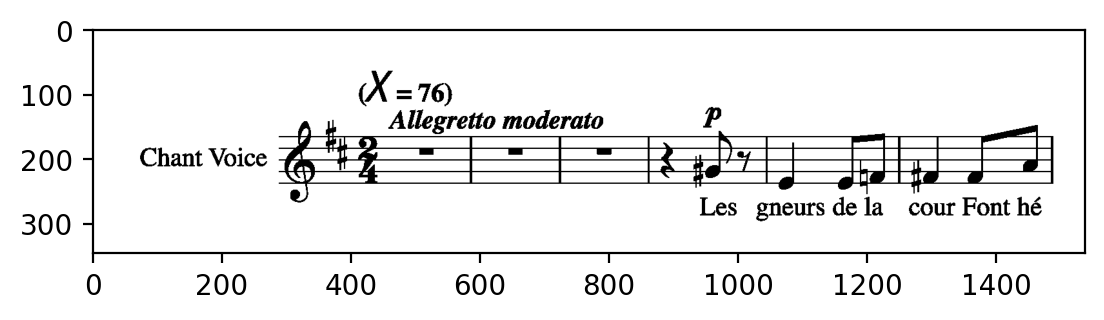

In [5]:
import json

example_image_path = TARGET_PATH / "w0_p0_m0to6_v4.png"
example_bboxes_path = example_image_path.with_suffix(".json")

with open(example_bboxes_path, "r") as f_bboxes:
    bboxes = json.load(f_bboxes)

foreground = np.array(Image.open(example_image_path).convert("RGB"))


showimg(foreground)

In [5]:
foreground.shape

(345, 1538, 3)

In [6]:
import cv2
import augraphy as aug
import random
import importlib
import image_ops

importlib.reload(image_ops)

INK_AUGMENTATIONS = [
    aug.InkBleed(
        intensity_range=(0.4, 0.9),
        kernel_size=random.choice([(7, 7), (5, 5), (3, 3)]),
        severity=(0.2, 0.9),
        p=0.3,
    ),
    aug.BleedThrough(
        intensity_range=(0.2, 0.8),
        color_range=(32, 224),
        ksize=(15, 31),
        sigmaX=1,
        alpha=random.uniform(0.1, 0.4),
        offsets=(10, 20),
        p=0.25,
    ),
    aug.InkShifter(
        text_shift_scale_range=(18, 36),
        text_shift_factor_range=(1, 5),
        text_fade_range=(0, 2),
        blur_kernel_size=(11, 11),
        blur_sigma=0.1,
        noise_type="random",
        p=0.25,
    ),
    aug.Letterpress(
        n_samples=(300, 800),
        n_clusters=(300, 800),
        std_range=(1500, 5000),
        value_range=(100, 220),
        value_threshold_range=(100, 255),
        blur=1,
        p=0.25,
    ),
    aug.InkColorSwap(
        ink_swap_color="random",
        ink_swap_sequence_number_range=(5, 10),
        ink_swap_min_width_range=(2, 3),
        ink_swap_max_width_range=(100, 120),
        ink_swap_min_height_range=(2, 3),
        ink_swap_max_height_range=(100, 120),
        ink_swap_min_area_range=(10, 40),
        ink_swap_max_area_range=(400, 500),
        p=0.5,
    ),
    aug.LinesDegradation(),
]

PAPER_AUGMENTATIONS = [
    image_ops.PaperFactory(
        texture_path=str(BACKGROUND_PATH),
        texture_enable_color=1,
        texture_color="Old",
        p=1.0,
    ),
    # aug.ColorPaper(
    #     p=1.0,
    # ),
    aug.ColorShift(),
    # aug.ColorPaper(hue_range=(0, 255), saturation_range=(0, 255)),
]

(428, 1804, 3)


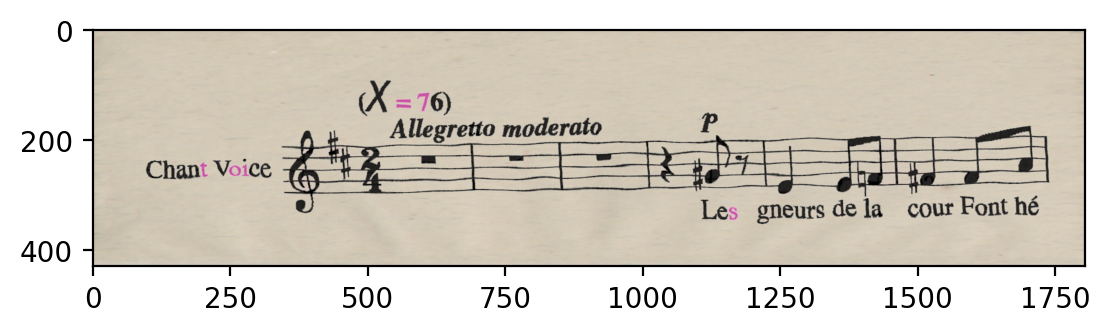

(440, 1841, 3)


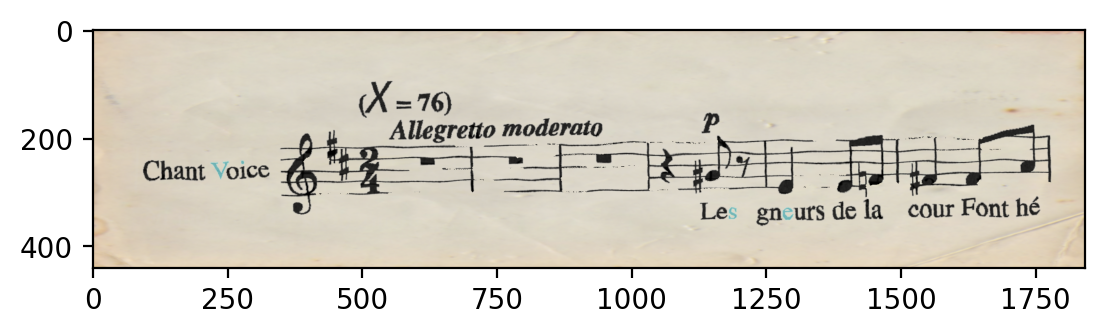

(446, 1829, 3)


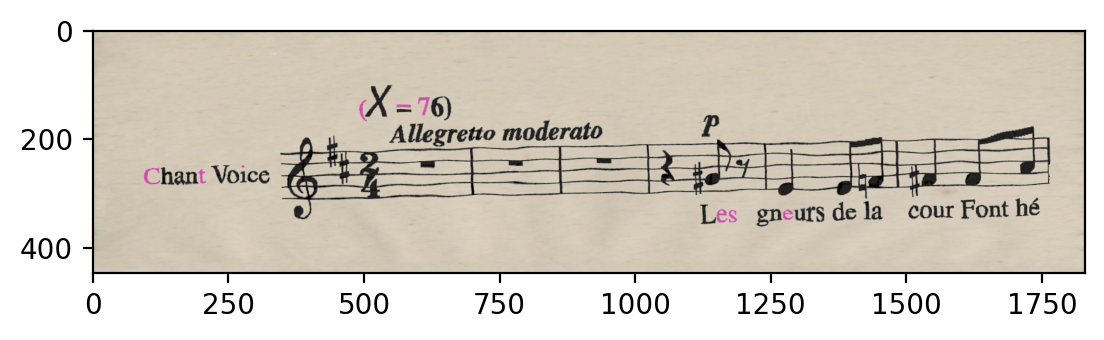

(456, 1799, 3)


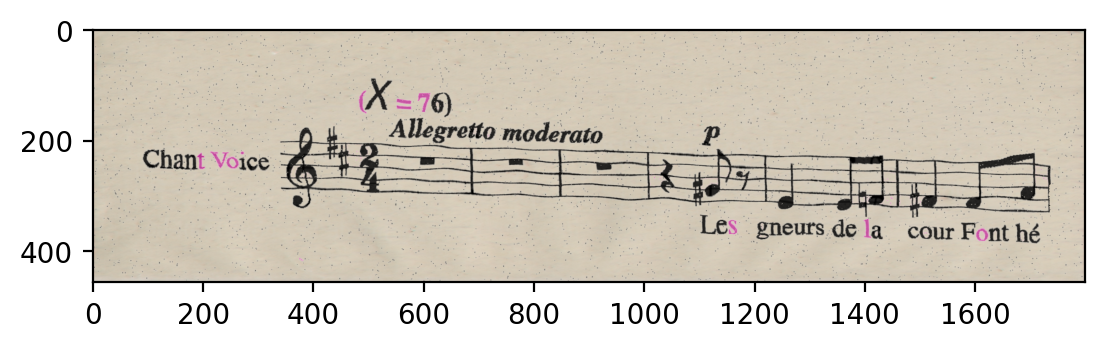

(457, 1767, 3)


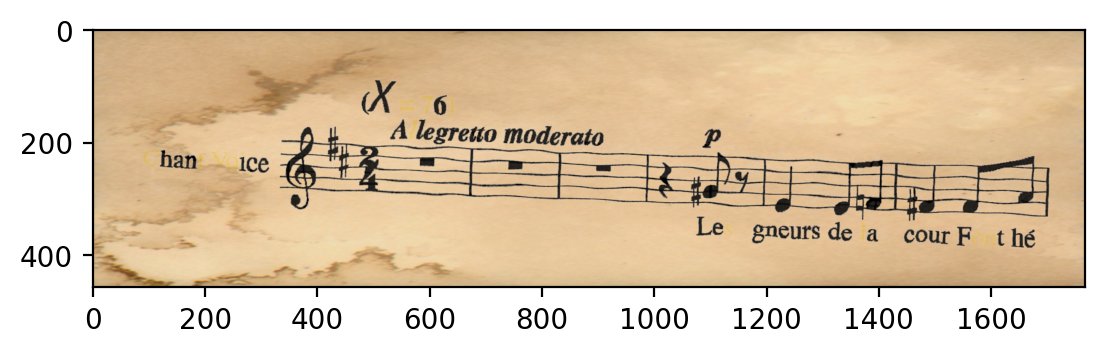

(441, 1769, 3)


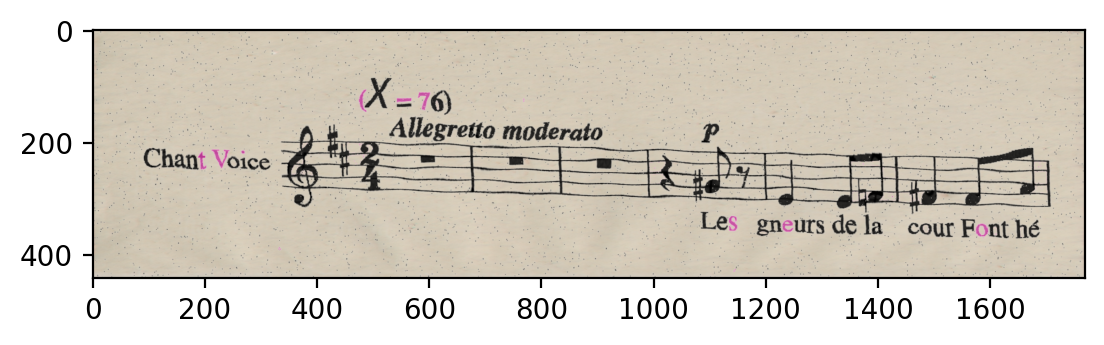

(388, 1565, 3)


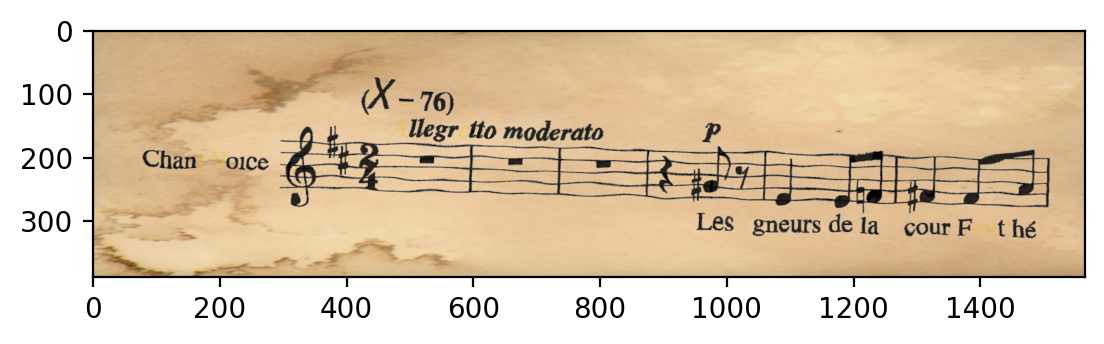

(442, 1725, 3)


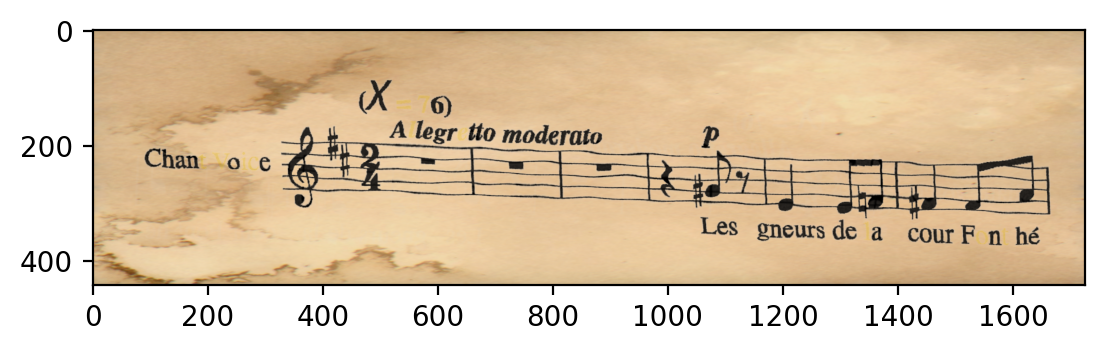

(388, 1597, 3)


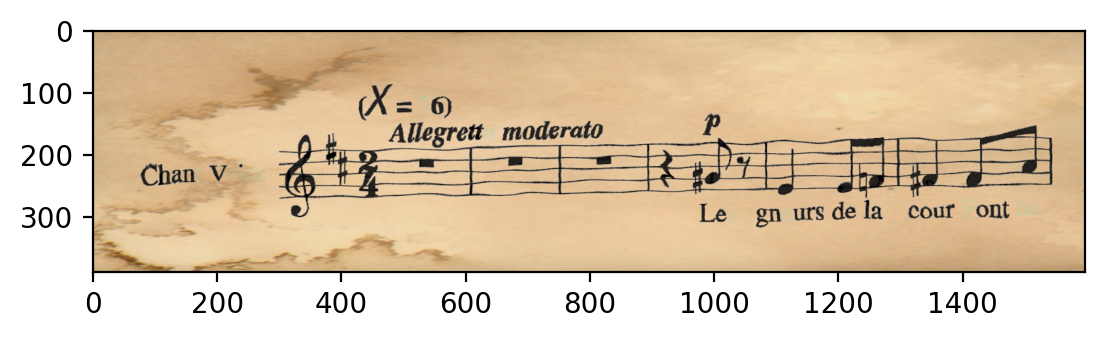

(428, 1661, 3)


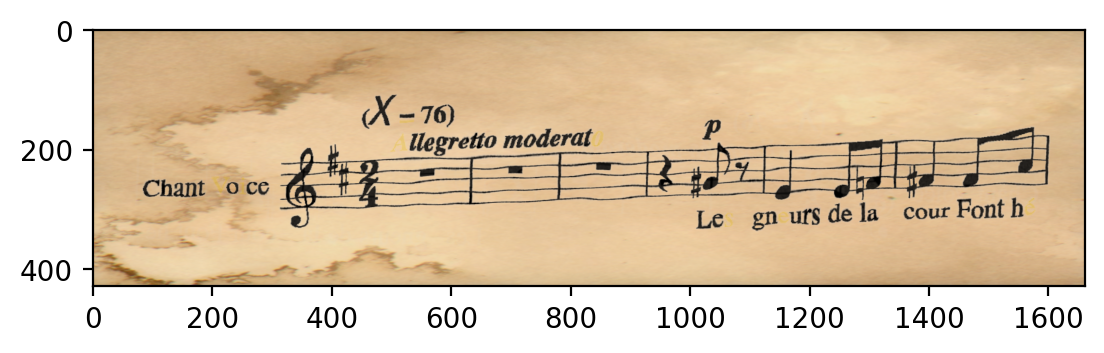

In [ ]:
import albumentations as alb

import cv2
import numpy as np

bbox_params = alb.BboxParams(coord_format="coco")
ALBUMENTATION_PIPELINE = alb.Compose(
    [
        alb.ElasticTransform(
            alpha=4.0,
            p=1,
            fill=(255, 255, 255),
        ),
        alb.Affine(
            scale=(1.0, 1.2),
            shear=(-3, 3),
            p=1.0,
            fill=(255, 255, 255),
            fit_output=True,
        ),
        alb.SaltAndPepper(amount_range=(0.01, 0.02), salt_vs_pepper_range=(1.0, 0.0)),
    ],
    bbox_params=bbox_params,
)

random.seed(42)
np.random.seed(42)
for _ in range(10):
    pipeline = aug.AugraphyPipeline(
        INK_AUGMENTATIONS,
        PAPER_AUGMENTATIONS,
        [],
        random_seed=18,
    )
    generated = pipeline(ALBUMENTATION_PIPELINE(image=foreground)["image"])
    print(generated.shape)
    image_output = cv2.cvtColor(generated, cv2.COLOR_BGR2RGB)
    Image.fromarray(image_output).save("test.png")
    showimg(image_output)

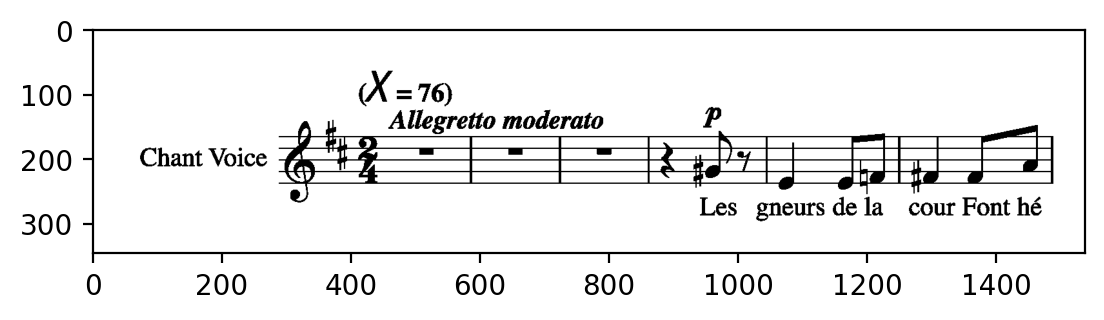

In [10]:
showimg(foreground)